## 1. 환경 + 의존성

In [ ]:
!nvidia-smi -L
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")


GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition (UUID: GPU-09f7f641-a2e8-9800-d1ea-d2cfbc6d379c)
PyTorch: 2.10.0+cu128, CUDA: True


In [ ]:
# transformers 최신 버전 (Depth Anything V2 지원)
!pip install -q -U transformers
!pip install -q scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 202.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. 경로 설정

In [ ]:
import os
from pathlib import Path

TEST_IMAGE_DIR = "/content/drive/MyDrive/capstone/test1_school_frames_2fps"
OUTPUT_DIR = "/content/drive/MyDrive/capstone/results/depth_anything_v2_metric"
os.makedirs(OUTPUT_DIR, exist_ok=True)

img_files = sorted([p for p in Path(TEST_IMAGE_DIR).iterdir()
                    if p.suffix.lower() in ['.jpg', '.jpeg', '.png']])
print(f"테스트 이미지: {len(img_files)}장")
print(f"결과 경로: {OUTPUT_DIR}")


테스트 이미지: 93장
결과 경로: /content/drive/MyDrive/capstone/results/depth_anything_v2_metric


## 3. 모델 로드 (자동 다운로드)

처음 실행 시 약 400MB 다운로드. Drive에 캐싱되므로 두 번째부턴 빠름.

`Depth-Anything-V2-Metric-Outdoor-Base-hf`:
- VKITTI에서 fine-tune된 outdoor 전용 metric 모델
- max_depth = 80m


In [ ]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'cuda' if device == 0 else 'cpu'}")

# Outdoor metric 모델 (보행 시나리오용)
MODEL_NAME = "depth-anything/Depth-Anything-V2-Metric-Outdoor-Base-hf"

print(f"\n{MODEL_NAME} 로드 중... (첫 실행 시 ~400MB 다운로드)")
pipe = pipeline(
    task="depth-estimation",
    model=MODEL_NAME,
    device=device,
)
print("모델 로드 완료")


Device: cuda

depth-anything/Depth-Anything-V2-Metric-Outdoor-Base-hf 로드 중... (첫 실행 시 ~400MB 다운로드)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/390M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

모델 로드 완료


## 4. 단일 이미지 테스트

첫 이미지로 metric depth 분포 확인.
실제 거리가 합리적으로 나오는지 검증.


테스트 이미지: frame_00000.jpg
크기: (1280, 720)

추론 시간: 955.4 ms
Depth shape: (720, 1280)
Depth 통계 (미터):
  min:    2.37 m
  max:    75.42 m
  median: 18.99 m
  mean:   26.44 m

거리 구간별 픽셀 비율:
   0.0 ~  1.5m:   0.0%  
   1.5 ~  3.0m:   0.0%  
   3.0 ~  5.0m:   0.0%  
   5.0 ~ 10.0m:  23.8%  ███████████
  10.0 ~ 30.0m:  40.6%  ████████████████████
  30.0 ~ 80.0m:  35.6%  █████████████████


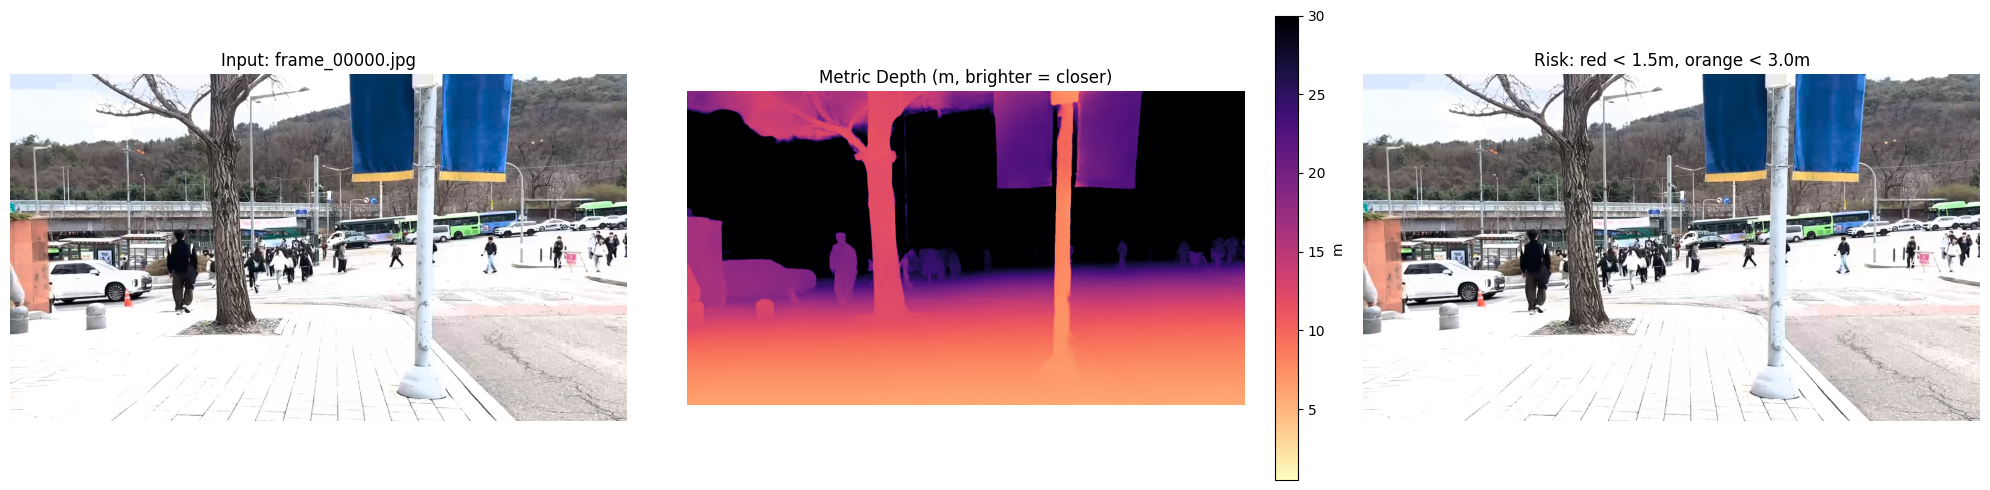

In [ ]:
from PIL import Image
import numpy as np
import time
import matplotlib.pyplot as plt

# 첫 이미지
test_path = img_files[0]
test_img = Image.open(test_path).convert('RGB')
print(f"테스트 이미지: {test_path.name}")
print(f"크기: {test_img.size}")

# 추론
torch.cuda.synchronize() if torch.cuda.is_available() else None
t0 = time.time()
result = pipe(test_img)
torch.cuda.synchronize() if torch.cuda.is_available() else None
elapsed_ms = (time.time() - t0) * 1000

# result['predicted_depth']는 torch tensor (미터 단위!)
depth_m = result['predicted_depth'].squeeze().cpu().numpy()
print(f"\n추론 시간: {elapsed_ms:.1f} ms")
print(f"Depth shape: {depth_m.shape}")
print(f"Depth 통계 (미터):")
print(f"  min:    {depth_m.min():.2f} m")
print(f"  max:    {depth_m.max():.2f} m")
print(f"  median: {np.median(depth_m):.2f} m")
print(f"  mean:   {depth_m.mean():.2f} m")

# 거리 구간별 분포
print(f"\n거리 구간별 픽셀 비율:")
for lo, hi in [(0, 1.5), (1.5, 3), (3, 5), (5, 10), (10, 30), (30, 80)]:
    pct = ((depth_m >= lo) & (depth_m < hi)).mean() * 100
    bar = '█' * int(pct / 2)
    print(f"  {lo:>4.1f} ~ {hi:>4.1f}m: {pct:5.1f}%  {bar}")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].imshow(test_img)
axes[0].set_title(f'Input: {test_path.name}')
axes[0].axis('off')

# Depth 시각화 (가까울수록 밝음)
im = axes[1].imshow(depth_m, cmap='magma_r', vmin=0.5, vmax=30)
axes[1].set_title(f'Metric Depth (m, brighter = closer)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='m', fraction=0.046)

# 3m 이내 영역 강조
img_resized = test_img.resize(depth_m.shape[::-1])
axes[2].imshow(img_resized)
H, W = depth_m.shape
urgent_mask = depth_m < 1.5
alert_mask = (depth_m < 3.0) & ~urgent_mask
overlay = np.zeros((H, W, 4))
overlay[alert_mask] = [1, 0.5, 0, 0.4]
overlay[urgent_mask] = [1, 0, 0, 0.6]
axes[2].imshow(overlay)
axes[2].set_title(f'Risk: red < 1.5m, orange < 3.0m')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '_sanity_check.png'), dpi=120, bbox_inches='tight')
plt.show()


## 5. 위험 판정 함수 (자동차 후방 센서 모방)

- `depth < 3.0` → ALERT
- `depth < 1.5` → URGENT
- 자동차 후방 센서와 동일 동작


In [ ]:
from scipy import ndimage

# 위험 판정 임계값 (미터)
URGENT_DISTANCE_M = 3.0
ALERT_DISTANCE_M = 4.5
MIN_OBSTACLE_PIXELS = 100  # 노이즈 방지 (모델 출력 해상도 기준)


def predict_depth(pil_image):
    """metric depth (m) 직접 반환."""
    result = pipe(pil_image)
    return result['predicted_depth'].squeeze().cpu().numpy()


def analyze_zones(depth_m,
                  alert_m=ALERT_DISTANCE_M,
                  urgent_m=URGENT_DISTANCE_M,
                  min_pixels=MIN_OBSTACLE_PIXELS):
    """좌/중/우 zone별 위험 판정 — 미터 기반."""
    H, W = depth_m.shape
    # 보행자 시야 ROI (위 30%는 하늘/멀리, 제외)
    roi = depth_m[int(H * 0.30):, :]
    rH, rW = roi.shape

    zones = {
        '왼쪽':   roi[:, :rW // 3],
        '중앙':   roi[:, rW // 3:2 * rW // 3],
        '오른쪽': roi[:, 2 * rW // 3:],
    }

    results = {}
    for name, z in zones.items():
        # nearest_5p = float(np.percentile(z, 5))  # 가장 가까운 5%
        nearest_5p = float(np.sort(z.flatten())[:10].max())
        urgent_pixels = int((z < urgent_m).sum())
        alert_pixels = int((z < alert_m).sum())

        if urgent_pixels >= min_pixels:
            status, priority = '즉시 정지', 2
        elif alert_pixels >= min_pixels:
            status, priority = '주의', 1
        else:
            status, priority = '안전', 0

        results[name] = {
            'nearest_distance_m': round(nearest_5p, 2),
            'pixels_within_3m': alert_pixels,
            'pixels_within_1.5m': urgent_pixels,
            'status': status,
            'priority': priority,
        }
    return results


def find_close_obstacles(depth_m,
                          alert_m=ALERT_DISTANCE_M,
                          min_pixels=MIN_OBSTACLE_PIXELS):
    """Connected component로 객체 단위 그룹핑."""
    H, W = depth_m.shape
    roi = depth_m[int(H * 0.30):, :]
    danger_mask = roi < alert_m

    labels, n_objects = ndimage.label(danger_mask)
    obstacles = []
    for i in range(1, n_objects + 1):
        obj_mask = labels == i
        size = int(obj_mask.sum())
        if size < min_pixels:
            continue
        distance = float(roi[obj_mask].min())
        ys, xs = np.where(obj_mask)
        center_x = xs.mean() / W
        if center_x < 1/3:
            direction = '왼쪽'
        elif center_x < 2/3:
            direction = '중앙'
        else:
            direction = '오른쪽'
        obstacles.append({
            'distance_m': round(distance, 2),
            'size_pixels': size,
            'center_x_ratio': round(center_x, 2),
            'direction': direction,
        })
    obstacles.sort(key=lambda x: x['distance_m'])
    return obstacles


print("위험 판정 함수 정의 완료")
print(f"  URGENT < {URGENT_DISTANCE_M}m, ALERT < {ALERT_DISTANCE_M}m")
print(f"  최소 객체 크기: {MIN_OBSTACLE_PIXELS} 픽셀")


위험 판정 함수 정의 완료
  URGENT < 3.0m, ALERT < 4.5m
  최소 객체 크기: 100 픽셀


## 6. 단일 이미지 위험 판정

In [ ]:
# 첫 이미지로 위험 판정 테스트
depth_m = predict_depth(test_img)
zone_results = analyze_zones(depth_m)
obstacles = find_close_obstacles(depth_m)

print(f"=== Zone 판정 ===")
for zone, info in zone_results.items():
    print(f"  {zone}: 최근접 {info['nearest_distance_m']}m, "
          f"3m이내 {info['pixels_within_3m']}px → {info['status']}")

print(f"\n=== 객체 판정 ({len(obstacles)}개) ===")
for i, obs in enumerate(obstacles[:5]):
    print(f"  [{i+1}] {obs['direction']} {obs['distance_m']}m (크기 {obs['size_pixels']}px)")

# 음성 안내 시뮬레이션
print(f"\n=== 음성 안내 ===")
if obstacles:
    closest = obstacles[0]
    if closest['distance_m'] < URGENT_DISTANCE_M:
        msg = f"정지! {closest['direction']} {closest['distance_m']:.1f}미터 앞 장애물"
    elif closest['distance_m'] < ALERT_DISTANCE_M:
        msg = f"주의: {closest['direction']} {closest['distance_m']:.1f}미터 앞 장애물"
    else:
        msg = "안전 (3m 안 객체 없음)"
    print(f"  → {msg}")
else:
    print(f"  → 안전")


=== Zone 판정 ===
  왼쪽: 최근접 5.97m, 3m이내 0px → 안전
  중앙: 최근접 2.56m, 3m이내 40px → 안전
  오른쪽: 최근접 3.27m, 3m이내 22px → 안전

=== 객체 판정 (0개) ===

=== 음성 안내 ===
  → 안전


## 7. 93장 일괄 처리

In [ ]:
import json
from tqdm import tqdm

viz_dir = os.path.join(OUTPUT_DIR, 'visualizations')
depth_npy_dir = os.path.join(OUTPUT_DIR, 'depth_npy')
os.makedirs(viz_dir, exist_ok=True)
os.makedirs(depth_npy_dir, exist_ok=True)

# 시간 측정용
times = {
    'preprocess': [],   # 이미지 로딩 + RGB 변환
    'inference': [],    # 모델 추론
    'postprocess': [],  # 위험 판정 (zone + 객체)
    'visualize': [],    # 시각화 + 저장
    'total': [],        # 전체
}

all_results = []

for img_path in tqdm(img_files, desc="Processing"):
    t_total_start = time.time()

    # ── 1. Preprocess: 이미지 로딩 ──
    t0 = time.time()
    pil_img = Image.open(img_path).convert('RGB')
    times['preprocess'].append((time.time() - t0) * 1000)

    # ── 2. Inference: 모델 추론 ──
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    t0 = time.time()
    depth_m = predict_depth(pil_img)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    times['inference'].append((time.time() - t0) * 1000)

    # ── 3. Postprocess: 위험 판정 ──
    t0 = time.time()
    zone_results = analyze_zones(depth_m)
    obstacles = find_close_obstacles(depth_m)

    if obstacles:
        closest = obstacles[0]
        if closest['distance_m'] < URGENT_DISTANCE_M:
            voice_msg = f"정지! {closest['direction']} {closest['distance_m']:.1f}미터 앞 장애물"
            alert_level = 'urgent'
        elif closest['distance_m'] < ALERT_DISTANCE_M:
            voice_msg = f"주의: {closest['direction']} {closest['distance_m']:.1f}미터 앞 장애물"
            alert_level = 'alert'
        else:
            voice_msg, alert_level = "", 'safe'
    else:
        voice_msg, alert_level = "", 'safe'
    times['postprocess'].append((time.time() - t0) * 1000)

    all_results.append({
        'image': img_path.name,
        'depth_stats': {
            'min': round(float(depth_m.min()), 2),
            'max': round(float(depth_m.max()), 2),
            'median': round(float(np.median(depth_m)), 2),
        },
        'zones': zone_results,
        'obstacles': obstacles[:5],
        'voice_message': voice_msg,
        'alert_level': alert_level,
        'timing_ms': {
            'preprocess': round(times['preprocess'][-1], 2),
            'inference': round(times['inference'][-1], 2),
        },
    })

    np.save(os.path.join(depth_npy_dir, img_path.stem + '.npy'),
            depth_m.astype(np.float16))

    # ── 4. Visualize ──
    t0 = time.time()
    H, W = depth_m.shape
    img_resized = pil_img.resize((W, H))

    # ROI 마스크 (analyze_zones와 동일하게 위 30% 제외)
    roi_mask = np.zeros((H, W), dtype=bool)
    roi_mask[int(H * 0.30):, :] = True

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title(img_path.name)
    axes[0].axis('off')

    im = axes[1].imshow(depth_m, cmap='magma_r', vmin=0.5, vmax=30)
    axes[1].set_title('Depth (m)')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], label='m', fraction=0.046)

    axes[2].imshow(img_resized)
    # ROI 안에서만 mask 적용 (위험 판정과 일치)
    urgent_mask = (depth_m < URGENT_DISTANCE_M) & roi_mask
    alert_mask = (depth_m < ALERT_DISTANCE_M) & ~urgent_mask & roi_mask
    overlay = np.zeros((H, W, 4))
    overlay[alert_mask] = [1, 0.5, 0, 0.4]
    overlay[urgent_mask] = [1, 0, 0, 0.6]
    axes[2].imshow(overlay)

    # 제목에 실제 임계값 사용 (하드코딩 X)
    title = alert_level.upper()
    if voice_msg:
        title += f": {voice_msg}"
    title += f"\n(red < {URGENT_DISTANCE_M}m, orange < {ALERT_DISTANCE_M}m)"
    axes[2].set_title(title, fontsize=10)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, img_path.stem + '_result.png'),
                dpi=80, bbox_inches='tight')
    plt.close(fig)
    times['visualize'].append((time.time() - t0) * 1000)

    times['total'].append((time.time() - t_total_start) * 1000)

with open(os.path.join(OUTPUT_DIR, 'all_results.json'), 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

# ── 속도 통계 ──
print(f"\n{len(all_results)}장 처리 완료")
print(f"\n{'='*60}")
print(f"단계별 속도 (ms 단위, {len(all_results)}장 평균)")
print(f"{'='*60}")
print(f"{'단계':<15} {'평균':>8} {'최소':>8} {'최대':>8} {'중앙값':>8}")
print(f"{'-'*60}")
for stage in ['preprocess', 'inference', 'postprocess', 'visualize', 'total']:
    arr = np.array(times[stage])
    print(f"{stage:<15} {arr.mean():>7.1f}ms {arr.min():>7.1f}ms "
          f"{arr.max():>7.1f}ms {np.median(arr):>7.1f}ms")

print(f"\n{'='*60}")
print(f"FPS 계산 (이미지 저장 제외 = 실시간 운영 환경)")
print(f"{'='*60}")
realtime_ms = np.mean(times['preprocess']) + np.mean(times['inference']) + np.mean(times['postprocess'])
total_ms = np.mean(times['total'])
print(f"  실시간 처리 (preprocess+inference+postprocess):")
print(f"     {realtime_ms:.1f} ms/frame → {1000/realtime_ms:.1f} FPS")
print(f"  추론만:")
print(f"     {np.mean(times['inference']):.1f} ms/frame → {1000/np.mean(times['inference']):.1f} FPS")
print(f"  전체 (시각화 저장 포함):")
print(f"     {total_ms:.1f} ms/frame → {1000/total_ms:.1f} FPS")

print(f"\n결과 저장: {OUTPUT_DIR}")

Processing:   6%|▋         | 6/93 [00:11<02:45,  1.91s/it]/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2972/4286269217.py:110: UserWarning: Glyph 53552 (\N{HANG


93장 처리 완료

단계별 속도 (ms 단위, 93장 평균)
단계                    평균       최소       최대      중앙값
------------------------------------------------------------
preprocess        614.7ms     4.4ms  1039.9ms   655.7ms
inference          32.4ms    31.1ms    34.6ms    32.4ms
postprocess         4.9ms     3.5ms    16.3ms     4.1ms
visualize         803.6ms   710.4ms  1606.2ms   759.7ms
total            1908.0ms  1520.9ms  2589.0ms  1905.8ms

FPS 계산 (이미지 저장 제외 = 실시간 운영 환경)
  실시간 처리 (preprocess+inference+postprocess):
     652.0 ms/frame → 1.5 FPS
  추론만:
     32.4 ms/frame → 30.8 FPS
  전체 (시각화 저장 포함):
     1908.0 ms/frame → 0.5 FPS

결과 저장: /content/drive/MyDrive/capstone/results/depth_anything_v2_metric


## 8. 통계 요약

=== Alert Level 분포 (93장) ===
   urgent:   6장 (  6.5%)
    alert:  11장 ( 11.8%)
     safe:  76장 ( 81.7%)

=== 최근접 객체 거리 분포 (미터) ===
  min:    0.50m
  median: 30.00m
  mean:   25.03m
  max:    30.00m


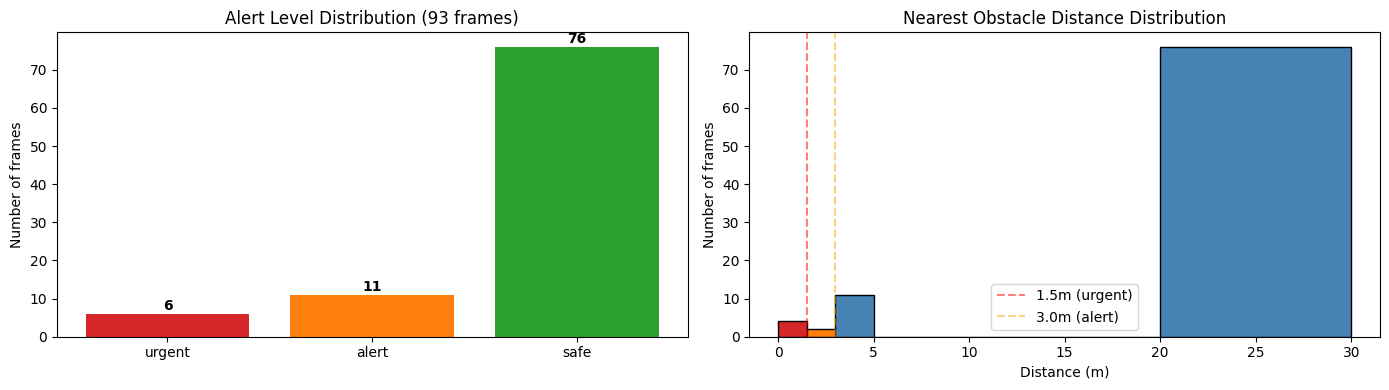

In [ ]:
from collections import Counter

alert_counts = Counter(r['alert_level'] for r in all_results)
print(f"=== Alert Level 분포 ({len(all_results)}장) ===")
for level in ['urgent', 'alert', 'safe']:
    n = alert_counts.get(level, 0)
    print(f"  {level:>7s}: {n:>3d}장 ({n/len(all_results)*100:5.1f}%)")

# 최근접 거리 분포
nearest_distances = []
for r in all_results:
    if r['obstacles']:
        nearest_distances.append(r['obstacles'][0]['distance_m'])
    else:
        nearest_distances.append(30.0)
nearest_distances = np.array(nearest_distances)

print(f"\n=== 최근접 객체 거리 분포 (미터) ===")
print(f"  min:    {nearest_distances.min():.2f}m")
print(f"  median: {np.median(nearest_distances):.2f}m")
print(f"  mean:   {nearest_distances.mean():.2f}m")
print(f"  max:    {nearest_distances.max():.2f}m")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

levels = ['urgent', 'alert', 'safe']
counts = [alert_counts.get(l, 0) for l in levels]
colors = ['#d62728', '#ff7f0e', '#2ca02c']
bars = axes[0].bar(levels, counts, color=colors)
for b, c in zip(bars, counts):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 str(c), ha='center', fontweight='bold')
axes[0].set_title(f'Alert Level Distribution ({len(all_results)} frames)')
axes[0].set_ylabel('Number of frames')

bins = [0, 1.5, 3.0, 5.0, 10.0, 20.0, 30.0]
n, bin_edges, patches = axes[1].hist(nearest_distances, bins=bins, edgecolor='black')
for i, p in enumerate(patches):
    bin_center = (bin_edges[i] + bin_edges[i+1]) / 2
    if bin_center < 1.5:
        p.set_facecolor('#d62728')
    elif bin_center < 3.0:
        p.set_facecolor('#ff7f0e')
    else:
        p.set_facecolor('steelblue')
axes[1].set_title('Nearest Obstacle Distance Distribution')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Number of frames')
axes[1].axvline(1.5, color='red', linestyle='--', alpha=0.5, label='1.5m (urgent)')
axes[1].axvline(3.0, color='orange', linestyle='--', alpha=0.5, label='3.0m (alert)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '_summary.png'), dpi=120, bbox_inches='tight')
plt.show()


## 9. 결과 확인

### 결과 위치
- `_sanity_check.png`: 첫 이미지 검증
- `_summary.png`: 93장 통계
- `visualizations/*.png`: 개별 결과
- `all_results.json`: JSON
- `depth_npy/*.npy`: depth map 원본

